# 序列模型


## 环境配置


In [1]:
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor with interal format")
import pypto
import torch
from torch import nn
import torch_npu
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('torch_npu.env').setLevel(logging.ERROR)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

## 练习8.1.1

改进本节实验中的模型。
1. 是否包含了过去4个以上的观测结果？真实值需要是多少个？
1. 如果没有噪音，需要多少个过去的观测结果？提示：把 sin 和 cos 写成微分方程。
1. 可以在保持特征总数不变的情况下合并旧的观察结果吗？这能提高正确度吗？为什么？
1. 改变神经网络架构并评估其性能。



### 1

**题目：** 是否包含了过去4个以上的观测结果？真实值需要是多少个？

**解答：** 原实验中 $\tau=4$ 意味着模型使用过去 4 个观测结果来预测当前值。通过增大 $\tau$ 参数（例如 $\tau=8$、$\tau=16$），可以让模型包含更多历史观测结果，从而捕捉更长期的时序依赖关系。n_train=600 决定了用于训练的样本数量（前 600 个时间步），剩余约 396 个样本可用于评估模型的泛化能力。真实值的个数取决于 $\tau$ 的选择：对于长度为 $T$ 的序列，可用样本总数为 $T - \tau$ 个。

以下使用 `torch` 编程进行验证：



epoch 1, loss: 0.063615
epoch 2, loss: 0.056863
epoch 3, loss: 0.053080


epoch 4, loss: 0.051665
epoch 5, loss: 0.051937


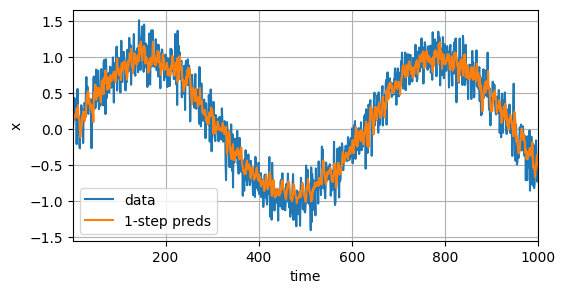

In [2]:
from src.utils import evaluate_loss, load_array, plot
import torch
from torch import nn

T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(tau, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, loss: {evaluate_loss(net, train_iter, loss):f}')

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

net = get_net()
train(net, train_iter, loss, 5, 0.01)


onestep_preds = net(features)
plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


使用 `PyPTO` 编程进行验证：



epoch 1, loss: 0.061836
epoch 2, loss: 0.057492


epoch 3, loss: 0.055384
epoch 4, loss: 0.053671


epoch 5, loss: 0.053599


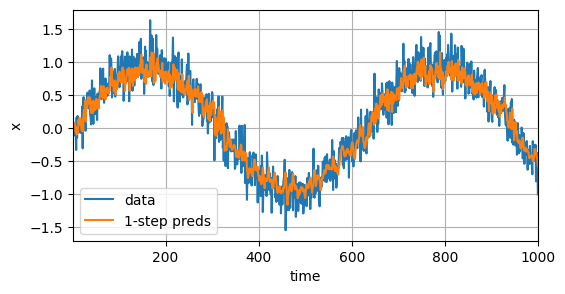

In [3]:
from src.utils import plot, load_array, evaluate_loss  # 本章节共享工具函数
from src.pypto_ops import PyPTOLinear, PyPTOReLU  # 本章节共享 PyPTO 算子

T = 1000
time_vals = torch.arange(1, T + 1, dtype=torch.float32, device=device)
x = torch.sin(0.01 * time_vals) + torch.normal(0, 0.2, (T,), device=device)

tau = 4
features = torch.zeros((T - tau, tau), device=device)
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]),
                        batch_size, is_train=True)

def init_weights(m):
    if isinstance(m, (nn.Linear, PyPTOLinear)):
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(
        PyPTOLinear(tau, 10),
        PyPTOReLU(),
        PyPTOLinear(10, 1)
    ).to(device)
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1},'
              f' loss: {evaluate_loss(net, train_iter, loss):f}')

net = get_net()

# Warmup
X, y = next(iter(train_iter))
l = loss(net(X), y)
l.sum().backward()
net.zero_grad()

train(net, train_iter, loss, 5, 0.01)

onestep_preds = net(features)
time_cpu = time_vals.cpu()
plot([time_cpu, time_cpu[tau:]],
     [x.detach().cpu().numpy(), onestep_preds.detach().cpu().numpy()], 'time',
     'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


### 2

**题目：** 如果没有噪音，需要多少个过去的观测结果？

**解答：** 由于 $\frac{d}{dx}\sin(x)=\cos(x)$，$\frac{d}{dx}\cos(x)=-\sin(x)$，$\sin$ 和 $\cos$ 的导数可以相互表示，因此通过微分方程只需要 $\tau=1$ 即可恢复完整信息。

以下使用 `torch` 编程进行验证：



epoch 1, loss: 0.009883
epoch 2, loss: 0.001904
epoch 3, loss: 0.001512


epoch 4, loss: 0.001300
epoch 5, loss: 0.001024


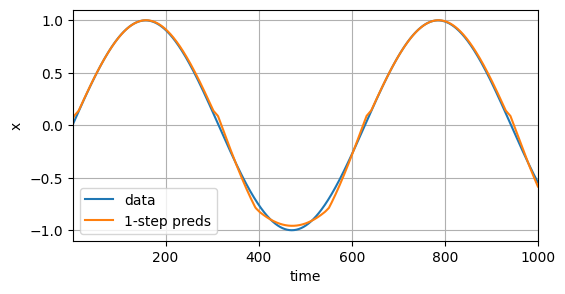

In [4]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time)  # 无噪声

tau = 1
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

def get_net():
    net = nn.Sequential(nn.Linear(tau, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

net = get_net()
train(net, train_iter, loss, 5, 0.01)

onestep_preds = net(features)
plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


使用 `PyPTO` 编程进行验证：



epoch 1, loss: 0.016328
epoch 2, loss: 0.004589


epoch 3, loss: 0.003762
epoch 4, loss: 0.002861


epoch 5, loss: 0.001984


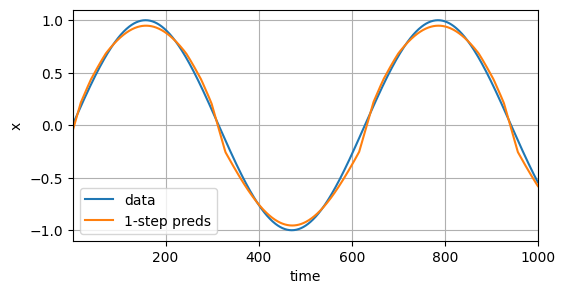

In [5]:
x_noiseless = torch.sin(0.01 * time_vals)

tau1 = 1
features1 = torch.zeros((T - tau1, tau1), device=device)
for i in range(tau1):
    features1[:, i] = x_noiseless[i: T - tau1 + i]
labels1 = x_noiseless[tau1:].reshape((-1, 1))

train_iter1 = load_array((features1[:n_train], labels1[:n_train]),
                          batch_size, is_train=True)

def get_net1():
    net = nn.Sequential(
        PyPTOLinear(1, 10),
        PyPTOReLU(),
        PyPTOLinear(10, 1)
    ).to(device)
    net.apply(init_weights)
    return net

net1 = get_net1()

# Warmup
X, y = next(iter(train_iter1))
l = loss(net1(X), y)
l.sum().backward()
net1.zero_grad()

train(net1, train_iter1, loss, 5, 0.01)

onestep_preds1 = net1(features1)
time_cpu = time_vals.cpu()
plot([time_cpu, time_cpu[tau1:]],
     [x_noiseless.detach().cpu().numpy(), onestep_preds1.detach().cpu().numpy()],
     'time', 'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


### 3

**题目：** 可以在保持特征总数不变的情况下合并旧的观察结果吗？这能提高正确度吗？为什么？

**解答：** 可以采用滑动窗口的方式生成特征矩阵，通过移动窗口起始位置而不增加新的特征维度。这可以提供更丰富的时序信息，捕捉序列数据中的时间相关性，从而有效提高预测准确度。

以下使用 `torch` 编程进行验证：



epoch 1, loss: 0.062919
epoch 2, loss: 0.058791
epoch 3, loss: 0.059551
epoch 4, loss: 0.056704


epoch 5, loss: 0.051695


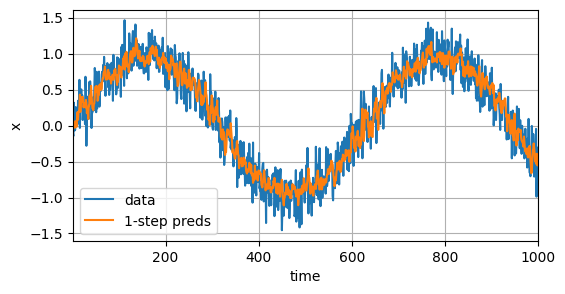

In [6]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

tau = 4
features = torch.zeros((T - tau, tau))
for i in range(T - tau):
    features[i] = x[i:i+tau]  # 滑动窗口
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

def get_net():
    net = nn.Sequential(nn.Linear(tau, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

net = get_net()
train(net, train_iter, loss, 5, 0.01)

onestep_preds = net(features)
plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


使用 `PyPTO` 编程进行验证：



epoch 1, loss: 0.066434
epoch 2, loss: 0.055710


epoch 3, loss: 0.051278
epoch 4, loss: 0.053065


epoch 5, loss: 0.047899


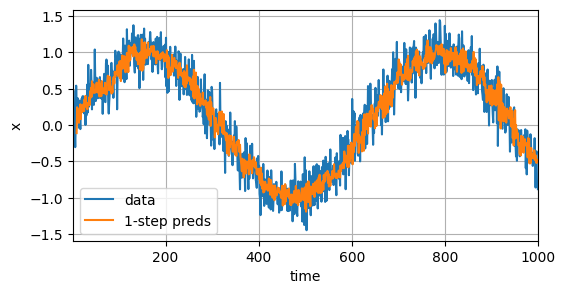

In [7]:
tau = 8  # 使用更多过去观测
T = 1000
time_vals = torch.arange(1, T + 1, dtype=torch.float32, device=device)
x = torch.sin(0.01 * time_vals) + torch.normal(0, 0.2, (T,), device=device)

# 隔点抽样：对过去 8 个观测每隔 2 个取 1 个（x[i*2: T - tau + i*2]），压缩为 4 维特征
features_sw = torch.zeros((T - tau, tau // 2), device=device)
for i in range(tau // 2):
    features_sw[:, i] = x[i*2: T - tau + i*2]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter_sw = load_array((features_sw[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

def get_net():
    net = nn.Sequential(
        PyPTOLinear(tau // 2, 10),
        PyPTOReLU(),
        PyPTOLinear(10, 1)
    ).to(device)
    net.apply(init_weights)
    return net

net_sw = get_net()

# Warmup
X, y = next(iter(train_iter_sw))
l = loss(net_sw(X), y)
l.sum().backward()
net_sw.zero_grad()

train(net_sw, train_iter_sw, loss, 5, 0.01)

onestep_preds_sw = net_sw(features_sw)
time_cpu = time_vals.cpu()
plot([time_cpu, time_cpu[tau:]],
     [x.detach().cpu().numpy(), onestep_preds_sw.detach().cpu().numpy()],
     'time', 'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


### 4

**题目：** 改变神经网络架构并评估其性能。

**解答：** 增加隐藏层大小和层数可降低 loss，但复杂结构可能在训练中出现振荡。

以下使用 `torch` 编程进行验证：



=== net_1 (4→10→1) ===
epoch 1, loss: 0.074596
epoch 2, loss: 0.058312
epoch 3, loss: 0.053994
epoch 4, loss: 0.052921


epoch 5, loss: 0.054436


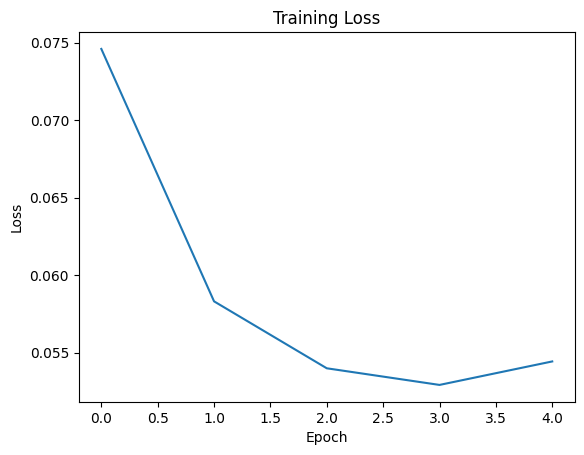

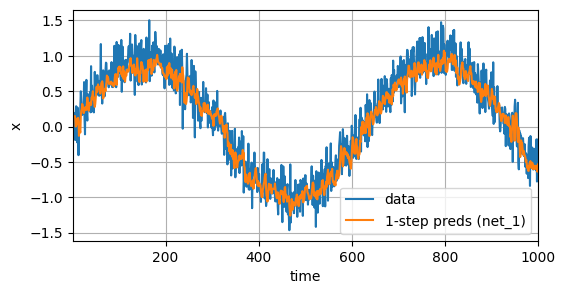

=== net_2 (4→50→10→1) ===
epoch 1, loss: 0.072621
epoch 2, loss: 0.053560
epoch 3, loss: 0.053423


epoch 4, loss: 0.053859
epoch 5, loss: 0.054696


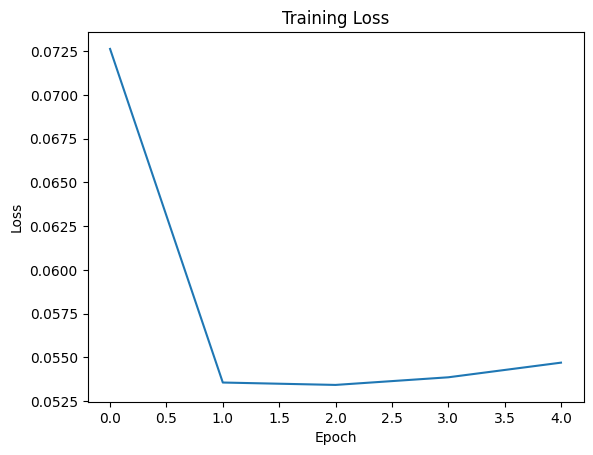

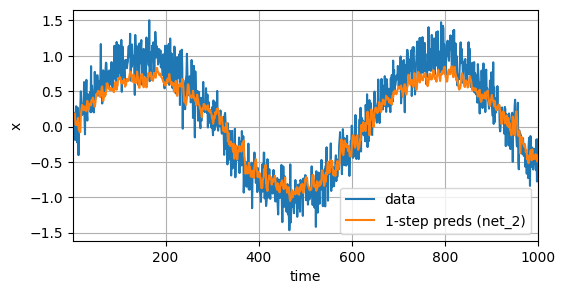

In [8]:
# 重新生成数据（使用普通特征矩阵）
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

def init_weights(m):  # 同 1 中定义
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():  # 同 2 中定义
    net = nn.Sequential(nn.Linear(tau, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

def new_get_net():
    net = nn.Sequential(nn.Linear(tau, 50), nn.ReLU(),
                        nn.Linear(50, 10), nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')  # 同 1 中定义

def train_draw(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
            epoch_loss += l.mean().item()
        epoch_loss /= len(train_iter)
        losses.append(epoch_loss)
        print(f'epoch {epoch + 1}, loss: {epoch_loss:f}')
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()

print("=== net_1 (4→10→1) ===")
net_1 = get_net()
train_draw(net_1, train_iter, loss, 5, 0.01)

onestep_preds_1 = net_1(features)
plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds_1.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds (net_1)'], xlim=[1, 1000],
         figsize=(6, 3))

print("=== net_2 (4→50→10→1) ===")
net_2 = new_get_net()
train_draw(net_2, train_iter, loss, 5, 0.01)

onestep_preds_2 = net_2(features)
plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds_2.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds (net_2)'], xlim=[1, 1000],
         figsize=(6, 3))


使用 `PyPTO` 编程进行验证：



=== net_1 (4→10→1) ===
epoch 1, loss: 0.262273


epoch 2, loss: 0.052384
epoch 3, loss: 0.049527


epoch 4, loss: 0.050253
epoch 5, loss: 0.048721


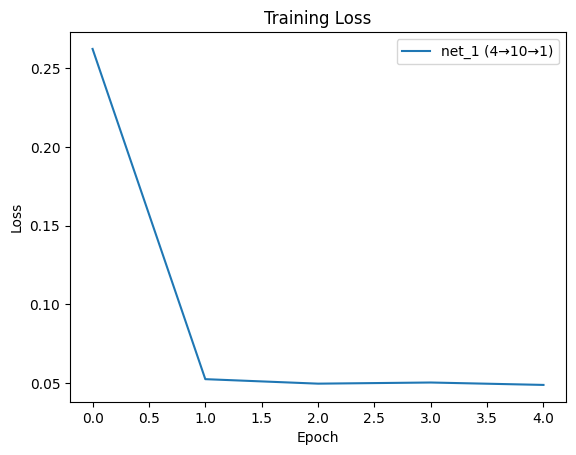

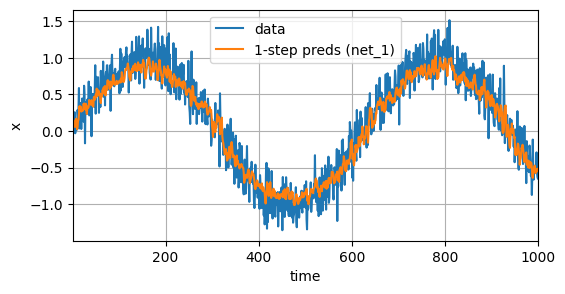

=== net_2 (4→50→10→1) ===


epoch 1, loss: 0.203255
epoch 2, loss: 0.053032


epoch 3, loss: 0.051770
epoch 4, loss: 0.055050


epoch 5, loss: 0.052238


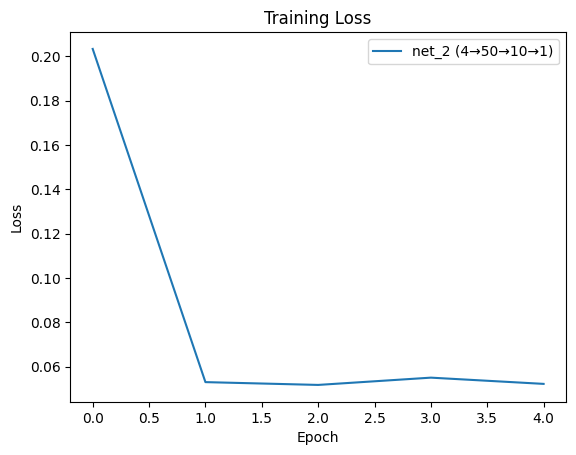

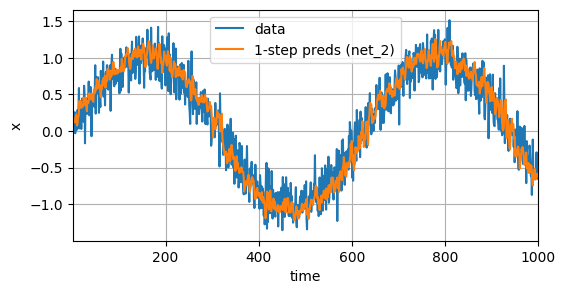

In [9]:
# 重新生成数据（使用普通特征矩阵）
tau = 4
T = 1000
time_vals = torch.arange(1, T + 1, dtype=torch.float32, device=device)
x = torch.sin(0.01 * time_vals) + torch.normal(0, 0.2, (T,), device=device)

features = torch.zeros((T - tau, tau), device=device)
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]),
                        batch_size, is_train=True)

def new_net():
    net = nn.Sequential(
        PyPTOLinear(tau, 50),
        PyPTOReLU(),
        PyPTOLinear(50, 10),
        PyPTOReLU(),
        PyPTOLinear(10, 1)
    ).to(device)
    net.apply(init_weights)
    return net

def train_draw(net, train_iter, loss, epochs, lr, label=''):
    trainer = torch.optim.Adam(net.parameters(), lr)
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
            epoch_loss += l.mean().item()
        epoch_loss /= len(train_iter)
        losses.append(epoch_loss)
        print(f'epoch {epoch + 1}, loss: {epoch_loss:f}')
    plt.plot(losses, label=label)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    if label:
        plt.legend()
    plt.show()

print("=== net_1 (4→10→1) ===")
def get_net():
    net = nn.Sequential(
        PyPTOLinear(tau, 10),
        PyPTOReLU(),
        PyPTOLinear(10, 1)
    ).to(device)
    net.apply(init_weights)
    return net

net_1 = get_net()

# Warmup
X, y = next(iter(train_iter))
l = loss(net_1(X), y)
l.sum().backward()
net_1.zero_grad()

train_draw(net_1, train_iter, loss, 5, 0.01, label='net_1 (4→10→1)')

onestep_preds_1 = net_1(features)
time_cpu = time_vals.cpu()
plot([time_cpu, time_cpu[tau:]],
     [x.detach().cpu().numpy(), onestep_preds_1.detach().cpu().numpy()],
     'time', 'x', legend=['data', '1-step preds (net_1)'],
     xlim=[1, 1000], figsize=(6, 3))

print("=== net_2 (4→50→10→1) ===")
net_2 = new_net()

# Warmup
X, y = next(iter(train_iter))
l = loss(net_2(X), y)
l.sum().backward()
net_2.zero_grad()

train_draw(net_2, train_iter, loss, 5, 0.01, label='net_2 (4→50→10→1)')

onestep_preds_2 = net_2(features)
plot([time_cpu, time_cpu[tau:]],
     [x.detach().cpu().numpy(), onestep_preds_2.detach().cpu().numpy()],
     'time', 'x', legend=['data', '1-step preds (net_2)'],
     xlim=[1, 1000], figsize=(6, 3))


## 练习8.1.2

**题目：** 一位投资者想要找到一种好的证券来购买。他查看过去的回报，以决定哪一种可能是表现良好的。这一策略可能会出什么问题呢？

**解答：** 该投资者仅采用过去回报预测未来属于外推法。外推法存在假设局限性：只有在过去历史可以用来预测未来趋势的前提下才有效。此外，外推法不能预测突发事件（政治事件、行业趋势和金融危机等），且非常依赖数据质量。对于金融证券，推荐结合基本面分析、市场情绪等多元因素建模以降低误差。



## 练习8.1.3

**题目：** 时间是向前推进的因果模型在多大程度上适用于文本呢？

**解答：** 时间向前推进的因果模型基于时间序列和因果关系，假设未来的结果受过去因素影响。但在文本数据中，时间序列并非影响未来文本结果产生的唯一因素，时序与文本内容的产生并无显著关联。文本生成受语义、语法、上下文等多维因素影响，单纯的时间因果关系不足以捕捉文本的复杂性，因此需要建立更复杂的模型（如注意力机制）。



## 练习8.1.4

**题目：** 举例说明什么时候可能需要隐变量自回归模型来捕捉数据的动力学模型。

**解答：** 隐变量自回归模型通过引入隐变量来捕捉未观测到的动态因素。例如：股票价格受历史价格（自回归）和市场情绪（隐变量）的共同影响；语音信号受前一帧信号（自回归）和说话人状态（隐变量）的影响；视频帧预测受前一帧（自回归）和物体运动趋势（隐变量）影响。



---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)

